# Part 1.

## (a)

In [236]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

load_digits_dataset = load_digits()
print(load_digits_dataset)


{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)), 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)), 'frame': None, 'feature_names': ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_

## (b)

The "load_digits" dataset contains a collection of 8x8 drawn images of digits ranging from 0-10. The images are kept as matrix arrays, containing values ranging from 0.0-16.0. It has 1797 instances in total. For each drawn image(instance) there are 64 pixels (features).

In [237]:
print("No. of classes:", len(np.unique(load_digits_dataset.target)))
print("Classes:", np.unique(load_digits_dataset.target))
print("Pixel min value:", load_digits_dataset.data.min())
print("Pixel max value:", load_digits_dataset.data.max())
print("No. of pixels for each image (features):", load_digits_dataset.data.shape[1])

No. of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel min value: 0.0
Pixel max value: 16.0
No. of pixels for each image (features): 64


## (c)

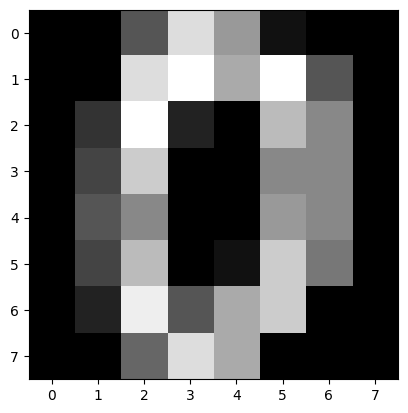

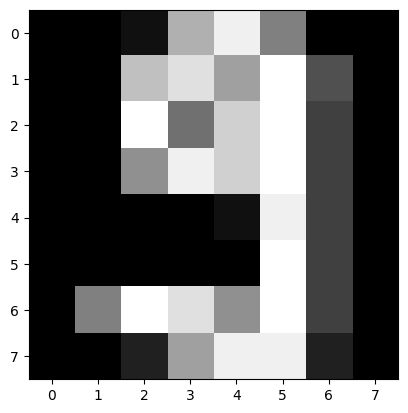

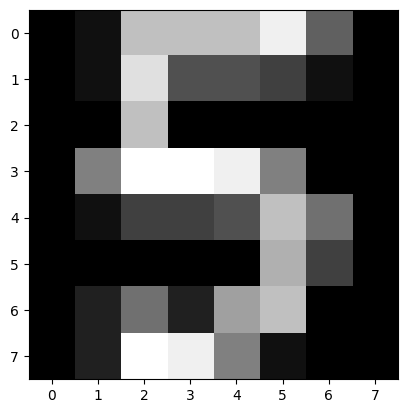

In [238]:
import matplotlib.pyplot as plt

plt.imshow(load_digits_dataset.images[0], cmap="grey")
plt.show()
plt.imshow(load_digits_dataset.images[128], cmap="grey")
plt.show()
plt.imshow(load_digits_dataset.images[1420], cmap="grey")
plt.show()

# there is no need to reshape, since it is already a matrix

## (d)

When it comes to K-means clustering, normalizing the data prevents high magnitude features from dominating other features in the distance calculations. For example, if we have a dataset where we're clustering based on income(1000) and age(21), income would be much higher than age and exaggerating the effect of income on the distance. Normalizing them makes them more easily comparable.

## (e)

We think the best approach would be use min-max scaling to normalize the pixel values. Because distance based algorithms like K-means work best with values that are in the range of 0.0-1.0.

# 2.

## (a)

In [239]:
from sklearn.cluster import KMeans

kmeans_cluster = KMeans(n_clusters=10,n_init="auto",random_state=42).fit(load_digits_dataset.data)
print(kmeans_cluster.inertia_)

1187766.2292515843


He above is the within sum of squared distances we got.

## (b)

In [240]:
from sklearn.metrics import adjusted_rand_score

cluster_labels = kmeans_cluster.labels_
target_labels = load_digits_dataset.target
ars = adjusted_rand_score(target_labels,cluster_labels)

print(ars)

0.725814218974996


As we can see here above, we got an Adjusted Random Score of 0.615. This indicates a good aggreement. It is significantly better than random chance, our clustering has discovered a real and meaningful structure in the data but not a perfect match.

## (c)

In [241]:
from sklearn.metrics import silhouette_score

labels = kmeans_cluster.fit_predict(load_digits_dataset.data)

sil_score = silhouette_score(load_digits_dataset.data, labels)

print(sil_score)

0.1764738746996612


As we can see here above, we got a silhouette score of 0.185. This indicates a weak structure but possibly some cluster pattern. We suspect that this might be because of similarities between some numbers, for example, 1 and 7 are look similar.

## (d)

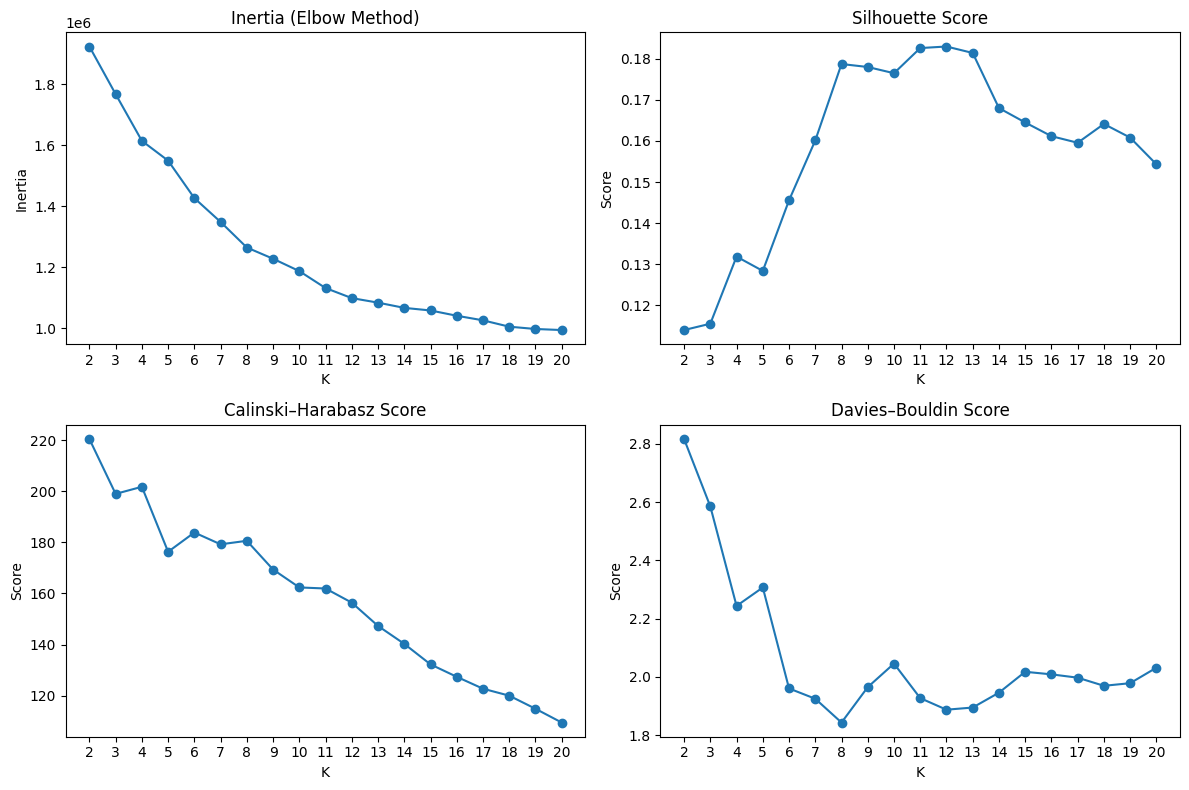

In [242]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

START_RANGE = 2
END_RANGE = 20
K_RANGE = range(START_RANGE,END_RANGE+1)

inertia_list = []
sil_list = []
ch_list = []
db_list = []

for k in K_RANGE:
    current_kmean = KMeans(n_clusters=k,random_state=42)
    current_labels = current_kmean.fit_predict(load_digits_dataset.data)

    inertia_list.append(current_kmean.inertia_)
    sil_list.append(silhouette_score(load_digits_dataset.data, current_labels))
    ch_list.append(calinski_harabasz_score(load_digits_dataset.data, current_labels))
    db_list.append(davies_bouldin_score(load_digits_dataset.data,current_labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

axes[0].set_xticks(list(K_RANGE))
axes[0].plot(K_RANGE, inertia_list, marker="o")
axes[0].set_title("Inertia (Elbow Method)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].set_xticks(list(K_RANGE))
axes[1].plot(K_RANGE, sil_list, marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")

axes[2].set_xticks(list(K_RANGE))
axes[2].plot(K_RANGE, ch_list, marker="o")
axes[2].set_title("Calinski–Harabasz Score")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Score")

axes[3].set_xticks(list(K_RANGE))
axes[3].plot(K_RANGE, db_list, marker="o")
axes[3].set_title("Davies–Bouldin Score")
axes[3].set_xlabel("K")
axes[3].set_ylabel("Score")

plt.tight_layout()
plt.show()

He above are plots depicting the stats we got from clustering with differen K values, ranging from 2 to 20. 

The conclusions we can draw from the plots...
- Inertia
  - We can find the best cluster by locating the "elbow" of the plot. The elbow is very ambigious When we look at the plot we got, we cannot gleam any optimal specific optimal cluster from this plot.
- Silhouette Score
  - We can find the best cluster by locating the peak silhouette value, because a high silhouette score indicates the most compact and well seperated clusters. Having 9 clusters resulted in the highest silhouette score.
- Calinski-Harabasz Score
  - We can find the best cluster by finding the highest ch score or when the value plateaus. It seems that the ch score plateaus right after 9 clusters is tried. This might indicated that having 9 clusters gives the best cluster.
  - Calinski-harabasz score measures the ratio betweencluster dispersion within cluster dispersion. Having a higher ch score means the clusters are denser and well seperated.
- Davies-Bouldin Score
  - We can find the best cluster by finding the lowest Davies-Bouldin score.The lowest Davies-Bouldin Score that comes up is when we have 9 clusters.
  - Davies bouldin score represents the average similarity between clusters, so having a lower score means that there is less overlap and tighter clusters.

We conclude that the optimal number of clusters for this dataset appears to be 9. Due to the results we've gleamed from our plots.

## (e)

First lets preprocess the data a bit, then run DBSCAN with various parameters to see which parameter combination(eps & min_sample) creates the most reasonable configuration. 

- eps
  - Having a way to small eps, makes way too many clusters and noise.
  - Having way to large eps, makes everything into one big cluster.

In [243]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

EPS_LIST = [1.5, 2.0, 3.0]
MIN_LIST = [5, 10, 20]

x = load_digits_dataset.data
y = load_digits_dataset.target

scaled_x = StandardScaler().fit_transform(x)
pca_x = PCA(n_components=30, random_state=42).fit_transform(scaled_x)

for current_eps in EPS_LIST:
  for current_sample in MIN_LIST:
    scan = DBSCAN(eps=current_eps, min_samples=current_sample)
    labels = scan.fit_predict(pca_x)

    cluster_amount = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    print("eps: ",current_eps," | min samples: ", current_sample, " | clusters: ", cluster_amount, " | noise: ", noise)


eps:  1.5  | min samples:  5  | clusters:  1  | noise:  1787
eps:  1.5  | min samples:  10  | clusters:  0  | noise:  1797
eps:  1.5  | min samples:  20  | clusters:  0  | noise:  1797
eps:  2.0  | min samples:  5  | clusters:  3  | noise:  1749
eps:  2.0  | min samples:  10  | clusters:  1  | noise:  1767
eps:  2.0  | min samples:  20  | clusters:  0  | noise:  1797
eps:  3.0  | min samples:  5  | clusters:  27  | noise:  1026
eps:  3.0  | min samples:  10  | clusters:  9  | noise:  1360
eps:  3.0  | min samples:  20  | clusters:  5  | noise:  1526


As we can see the parameter combination of eps=3.0 and min_samples=10 gave most reasonable amount of clusters(9) and noise(1360). 

Now lets evaluate the clustering quality of these parameters.

In [244]:
from sklearn.metrics import adjusted_mutual_info_score

db = DBSCAN(eps=3.0, min_samples=10)
labels = db.fit_predict(pca_x)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
ari = adjusted_rand_score(y, labels)
ami = adjusted_mutual_info_score(y, labels)

print("Estimated clusters: ",n_clusters)
print("ARI: ",ari," AMI: ", ami)

Estimated clusters:  9
ARI:  0.06371967764711384  AMI:  0.3601054446466962


As we can see here above, the DBSCAN found that there are 9 distinct clusters, which is close to the real number 10.
A adjusted rand index of 0.064 tells us that the cluster assignment does not align closely with the true labels. Their composition doesnt math the actual digits that well.
And finally, we got a 0.36 AMI which tells us that there is some shared information between the clusters found in DBSCAN and the true labels. So there is a partial correspondance.

# 3.

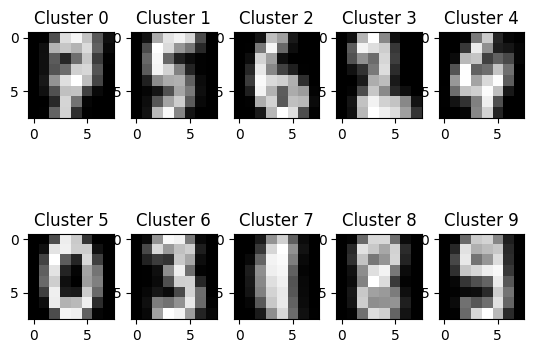

In [245]:
cluster_centre_list = []

for center in kmeans_cluster.cluster_centers_:
    cluster_centre_list.append(np.reshape(center,(8,8)))

fig, axes = plt.subplots(2, 5) 

axes = axes.flatten()

for i, (center, ax) in enumerate(zip(cluster_centre_list, axes)):
    ax.imshow(center, cmap="gray")
    ax.set_title("Cluster "+ str(i))

plt.show()

Here above are the plotted cluster centers. Some of them resemble numbers quite well, while others are very ambigious. This does align with our expectations, since cluster centers are the mean of all the samples in each cluster. Digits that have consistent shapes like 1 (cluster 7) and 0 (cluster 5) have much more sharper and more distinct clusters centers, while more complex shapes with higher variation like 8 (cluster 8) result in a much more blurrier plot.